--- Chargement : ../datasets/schaefcomb_Wang2023Simple_dfschizo.tsv ---


/tmp/ipykernel_1891977/1368050410.py:48: DtypeWarning: Columns (93968) have mixed types. Specify dtype option on import or set low_memory=False.
  df_all = pd.read_csv(DATA_PATH, sep="\t")



DÉBUT LOSO (REAL DATA) | PCA(100) + SVM (Linear) | Seed=42

🔹 SITE TEST : ds000030
   Best C: 0.0010
   AUC Interne : 0.708
   AUC Externe : 0.724  (Brier: 0.243)
   Youden Thresh: 0.54 | Acc: 0.703 | Sens: 0.720 | Spec: 0.697

🔹 SITE TEST : ds004302
   Best C: 1.0000
   AUC Interne : 0.634
   AUC Externe : 0.677  (Brier: 0.293)
   Youden Thresh: 0.39 | Acc: 0.676 | Sens: 0.717 | Spec: 0.600

🔹 SITE TEST : ds_cobre
   Best C: 0.0010
   AUC Interne : 0.652
   AUC Externe : 0.688  (Brier: 0.240)
   Youden Thresh: 0.43 | Acc: 0.644 | Sens: 0.681 | Spec: 0.608


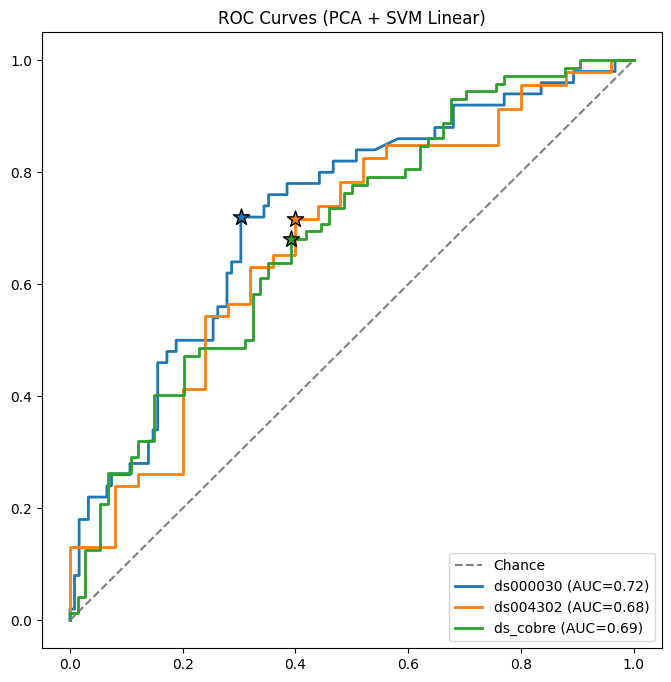

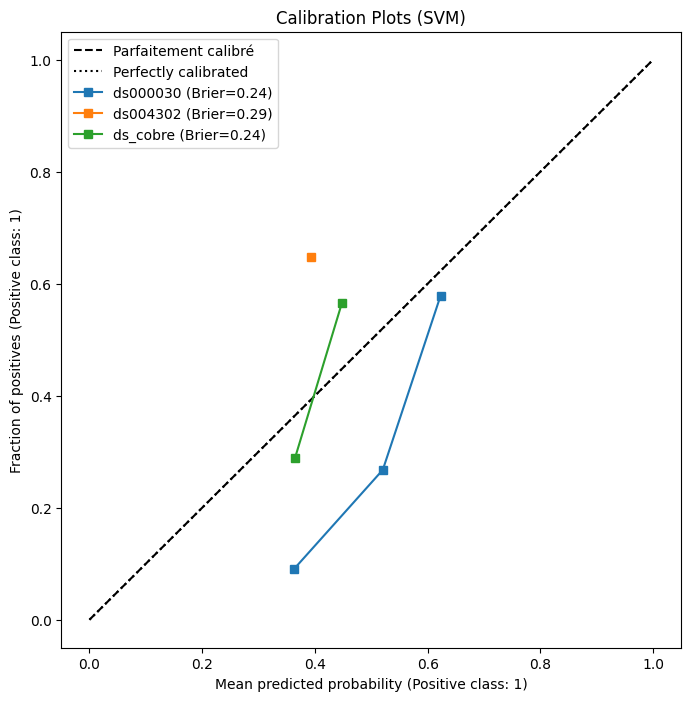


DÉBUT SANITY CHECK (LABELS ALÉATOIRES)
   Site ds000030 | AUC Random: 0.485


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.decomposition import PCA 
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.model_selection import LeaveOneGroupOut, GridSearchCV
from sklearn.metrics import roc_auc_score, brier_score_loss, roc_curve, accuracy_score, confusion_matrix
from sklearn.calibration import CalibrationDisplay
from nilearn import plotting
from nilearn.plotting import view_markers
from IPython.display import display

# ============================================================
# 0) REPRODUCTIBILITÉ (SEED FIXE)
# ============================================================
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# ============================================================
# CONFIGURATION
# ============================================================
DATA_PATH = "../datasets/schaefcomb_Wang2023Simple_dfschizo.tsv"
ATLAS_NII = "/scratch/pbergere/project_computational_medicine/atlas/atlas-Schaefer2018Combined_dseg.nii.gz"
ATLAS_TSV = "/scratch/pbergere/project_computational_medicine/atlas/atlas-Schaefer2018Combined_dseg.tsv"

# --- MODIFICATION ICI : Dossier de sortie pour SVM ---
OUTPUT_DIR = "../results_loso_pca_svm" 

CONF_METHOD = "regression"
INCLUDE_CONFOUNDS_IN_MODEL = False
conf_vars = ["age", "gender_num", "mean_fd"]

# PCA Configuration
N_PCA_COMPONENTS = 100

if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

# ============================================================
# 1) CHARGEMENT
# ============================================================
print(f"--- Chargement : {DATA_PATH} ---")
df_all = pd.read_csv(DATA_PATH, sep="\t")

mask_loso = (
    df_all["site_id"].isin(["ds000030", "ds_cobre", "ds004302"])
    & df_all["diagnosis"].isin(["CONTROL", "SCHZ"])
)
df_loso = df_all.loc[mask_loso].copy()

# Variables cliniques
df_loso["age"] = df_loso["age"].astype(float)
df_loso["gender_num"] = (df_loso["gender"] == "M").astype(float)

if "mean_fd" not in df_loso.columns:
    df_loso["mean_fd"] = 0.0
else:
    df_loso["mean_fd"] = df_loso["mean_fd"].astype(float)
    if df_loso["mean_fd"].isna().any():
        df_loso["mean_fd"] = df_loso["mean_fd"].fillna(df_loso["mean_fd"].median())

y_loso_all = (df_loso["diagnosis"] == "SCHZ").astype(int)
groups_loso = df_loso["site_id"].values

# ============================================================
# 2) CONNECTOMES (RAW)
# ============================================================
corr_cols_all = [c for c in df_loso.columns if c.startswith("corr_")]
X_temp = df_loso[corr_cols_all]
corr_cols = X_temp.columns[X_temp.notna().any()].tolist()
X_loso_raw = df_loso[corr_cols]

# ============================================================
# 3) FONCTIONS
# ============================================================

def residualize_confounds(X_train, X_test, conf_train, conf_test):
    imp = SimpleImputer(strategy="mean")
    X_train_imp = imp.fit_transform(X_train)
    X_test_imp = imp.transform(X_test)
    
    C_train = np.column_stack([np.ones(len(conf_train)), conf_train.values])
    C_test  = np.column_stack([np.ones(len(conf_test)),  conf_test.values])
    
    B = np.linalg.pinv(C_train).dot(X_train_imp)
    
    return (pd.DataFrame(X_train_imp - C_train.dot(B), index=X_train.index, columns=X_train.columns),
            pd.DataFrame(X_test_imp - C_test.dot(B), index=X_test.index, columns=X_test.columns))

def get_model():
    # --- MODIFICATION SVM ---
    # Nous utilisons GridSearchCV pour tuner le C, car SVC n'a pas de version "CV" intégrée
    # probability=True est requis pour Brier Score et Calibration Plot (utilise Platt Scaling)
    svm = SVC(
        kernel='linear', 
        probability=True, 
        class_weight='balanced', 
        random_state=RANDOM_SEED
    )
    
    # Grid Search sur C (paramètre de régularisation du SVM)
    # C petit = forte régularisation, C grand = faible régularisation
    param_grid = {'C': np.logspace(-3, 3, 7)}
    
    clf = GridSearchCV(
        estimator=svm,
        param_grid=param_grid,
        cv=5,
        scoring='roc_auc',
        n_jobs=-1
    )

    return Pipeline([
        ("imputer", SimpleImputer(strategy="mean")), 
        ("scaler", StandardScaler()), 
        ("pca", PCA(n_components=N_PCA_COMPONENTS, random_state=RANDOM_SEED)), 
        ("clf", clf) 
    ])

def calculate_youden_metrics(y_true, y_prob):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    J = tpr - fpr
    ix = np.argmax(J)
    best_thresh = thresholds[ix]
    
    y_pred = (y_prob >= best_thresh).astype(int)
    acc = accuracy_score(y_true, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    
    return best_thresh, acc, sens, spec, fpr[ix], tpr[ix]

# ============================================================
# 4) BOUCLE LOSO
# ============================================================
print("\n" + "="*60)
print(f"DÉBUT LOSO (REAL DATA) | PCA({N_PCA_COMPONENTS}) + SVM (Linear) | Seed={RANDOM_SEED}")
print("="*60)

logo = LeaveOneGroupOut()
loso_results = []
all_weights_data = []

fig_roc, ax_roc = plt.subplots(figsize=(8, 8))
ax_roc.plot([0, 1], [0, 1], "--", color="gray", label="Chance")
fig_cal, ax_cal = plt.subplots(figsize=(8, 8))
ax_cal.plot([0, 1], [0, 1], "--", color="black", label="Parfaitement calibré")
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

for i, (train_idx, test_idx) in enumerate(logo.split(X_loso_raw, y_loso_all, groups=groups_loso)):
    site_test_name = groups_loso[test_idx][0]
    print(f"\n🔹 SITE TEST : {site_test_name}")
    
    # 1. Split
    X_tr, X_te = X_loso_raw.iloc[train_idx], X_loso_raw.iloc[test_idx]
    y_tr, y_te = y_loso_all.iloc[train_idx], y_loso_all.iloc[test_idx]
    c_tr, c_te = df_loso.iloc[train_idx][conf_vars], df_loso.iloc[test_idx][conf_vars]

    # 2. Correction
    if CONF_METHOD == "regression":
        X_tr_cl, X_te_cl = residualize_confounds(X_tr, X_te, c_tr, c_te)
    else:
        X_tr_cl, X_te_cl = X_tr, X_te

    # 3. Fit
    pipeline = get_model()
    pipeline.fit(X_tr_cl, y_tr)
    
    # AUC CV Interne & Poids
    clf_obj = pipeline.named_steps['clf'] # Ceci est maintenant un GridSearchCV
    pca_obj = pipeline.named_steps['pca'] 
    
    # --- MODIFICATION POUR SVM/GridSearchCV ---
    # On récupère le meilleur score du GridSearch
    auc_internal = clf_obj.best_score_
    best_C = clf_obj.best_params_['C']
    print(f"   Best C: {best_C:.4f}")

    # 4. Predict
    # predict_proba fonctionne car probability=True dans SVC
    y_prob = pipeline.predict_proba(X_te_cl)[:, 1]
    
    # 5. Metrics
    auc_external = roc_auc_score(y_te, y_prob)
    brier = brier_score_loss(y_te, y_prob)
    
    thresh, acc, sens, spec, b_fpr, b_tpr = calculate_youden_metrics(y_te, y_prob)
    
    delta = auc_internal - auc_external
    print(f"   AUC Interne : {auc_internal:.3f}")
    print(f"   AUC Externe : {auc_external:.3f}  (Brier: {brier:.3f})")
    print(f"   Youden Thresh: {thresh:.2f} | Acc: {acc:.3f} | Sens: {sens:.3f} | Spec: {spec:.3f}")

    loso_results.append({
        "site": site_test_name, 
        "auc_internal": auc_internal,
        "auc_external": auc_external,
        "delta_auc": delta,
        "brier_score": brier,
        "accuracy": acc, 
        "sensitivity": sens, 
        "specificity": spec, 
        "optimal_threshold": thresh
    })

    # Plots
    color = colors[i % 3]
    fpr, tpr, _ = roc_curve(y_te, y_prob)
    ax_roc.plot(fpr, tpr, color=color, lw=2, label=f"{site_test_name} (AUC={auc_external:.2f})")
    ax_roc.scatter(b_fpr, b_tpr, color=color, s=150, marker='*', edgecolors='k', zorder=10)
    
    CalibrationDisplay.from_predictions(y_te, y_prob, n_bins=5, name=f"{site_test_name} (Brier={brier:.2f})", ax=ax_cal, color=color)

    # Weights Back-projection (Inverse Transform Logic)
    # --- MODIFICATION : Récupérer les coefs du meilleur estimateur du GridSearch ---
    # SVM lineaire possède un attribut .coef_
    svm_weights = clf_obj.best_estimator_.coef_.flatten() 
    
    # On projette ces poids sur l'espace original des features via pca.components_
    original_feature_weights = np.dot(svm_weights, pca_obj.components_)
    
    # Création du DF des poids sur les features ORIGINALES (corr_x_y)
    fold_weights_df = pd.DataFrame(index=X_tr_cl.columns)
    fold_weights_df["weight"] = original_feature_weights
    fold_weights_df["status"] = "Kept" 
    fold_weights_df["test_site"] = site_test_name
    fold_weights_df["feature_name"] = fold_weights_df.index
    
    all_weights_data.append(fold_weights_df)

ax_roc.set_title("ROC Curves (PCA + SVM Linear)")
ax_roc.legend(loc='lower right')
ax_cal.set_title("Calibration Plots (SVM)")
ax_cal.legend(loc='upper left')
plt.show()

# ============================================================
# 5) SANITY CHECK
# ============================================================
print("\n" + "="*60)
print(f"DÉBUT SANITY CHECK (LABELS ALÉATOIRES)")
print("="*60)

np.random.seed(RANDOM_SEED + 99) 
y_rand = pd.Series(np.random.permutation(y_loso_all), index=df_loso.index)
rand_results = []

for i, (train_idx, test_idx) in enumerate(logo.split(X_loso_raw, y_rand, groups=groups_loso)):
    site_test_name = groups_loso[test_idx][0]
    X_tr, X_te = X_loso_raw.iloc[train_idx], X_loso_raw.iloc[test_idx]
    y_tr, y_te = y_rand.iloc[train_idx], y_rand.iloc[test_idx]
    c_tr, c_te = df_loso.iloc[train_idx][conf_vars], df_loso.iloc[test_idx][conf_vars]
    
    if CONF_METHOD == "regression":
        X_tr_cl, X_te_cl = residualize_confounds(X_tr, X_te, c_tr, c_te)
    else:
        X_tr_cl, X_te_cl = X_tr, X_te
        
    pipeline = get_model()
    pipeline.fit(X_tr_cl, y_tr)
    y_prob = pipeline.predict_proba(X_te_cl)[:, 1]
    
    auc_r = roc_auc_score(y_te, y_prob)
    print(f"   Site {site_test_name} | AUC Random: {auc_r:.3f}")
    rand_results.append({"site": site_test_name, "auc_random": auc_r})

print(f"Moyenne AUC Random : {pd.DataFrame(rand_results)['auc_random'].mean():.3f}")

# ============================================================
# 6) EXPORT ET VISUALISATION
# ============================================================
print("\n" + "="*60)
print("RÉSULTATS FINAUX & EXPORT")
print("="*60)

df_res = pd.DataFrame(loso_results)
res_path = os.path.join(OUTPUT_DIR, "loso_metrics_performance_pca_svm.tsv")
df_res.to_csv(res_path, sep="\t", index=False)

# Affichage avec Brier Score
print(df_res[["site", "auc_external", "brier_score", "accuracy", "sensitivity", "specificity"]].round(3))
print(f"Moyenne AUC Externe : {df_res['auc_external'].mean():.3f}")
print(f"Moyenne Brier Score : {df_res['brier_score'].mean():.3f}")

df_all_weights = pd.concat(all_weights_data, ignore_index=True)
weights_path = os.path.join(OUTPUT_DIR, "loso_features_weights_pca_svm_projected.tsv")
df_all_weights.to_csv(weights_path, sep="\t", index=False)

n_features_active = len(df_all_weights[abs(df_all_weights["weight"]) > 1e-5]["feature_name"].unique())
print(f"\nNombre total de connexions (Poids projeté > 1e-5) : {n_features_active}")

print("\n--- GÉNÉRATION VISUALISATION 3D (CONSENSUS PCA -> ORIG) ---")
try:
    coords = plotting.find_parcellation_cut_coords(ATLAS_NII)
    n_rois = len(coords)
    df_labels = pd.read_csv(ATLAS_TSV, sep="\t", header=None)
    
    # Gestion atlas labels
    if df_labels.shape[1] > 1:
        roi_names = np.array(df_labels.iloc[:, 1].values)
    else:
        roi_names = np.array(df_labels.iloc[:, 0].values)
    
    # Moyenne des poids rétro-projetés sur les folds
    df_cons = df_all_weights.groupby("feature_name").agg({"weight": "mean"}).reset_index()
    roi_scores = np.zeros(n_rois)
    
    for _, row in df_cons.iterrows():
        try:
            w = abs(row["weight"])
            # Filtre de bruit 
            if w > 1e-5: 
                parts = row["feature_name"].split("_")
                # Format attendu : corr_1_2
                idx1, idx2 = int(parts[1]) - 1, int(parts[2]) - 1
                if idx1 < n_rois and idx2 < n_rois:
                    roi_scores[idx1] += w
                    roi_scores[idx2] += w
        except: pass
    
    if roi_scores.max() > 0:
        ranked_indices = np.argsort(roi_scores)[::-1]
        final_colors = np.array([""] * n_rois, dtype=object)
        final_sizes = np.zeros(n_rois)
        cmap_top = plt.get_cmap('YlOrRd')
        limit_top = 100 # On affiche le top 100 des noeuds les plus influents

        for rank, roi_idx in enumerate(ranked_indices):
            if rank < limit_top and roi_scores[roi_idx] > 0:
                normalized_rank = 1.0 - (rank / limit_top)
                rgba = cmap_top(normalized_rank)
                final_colors[roi_idx] = mcolors.to_hex(rgba)
                final_sizes[roi_idx] = 4 + (normalized_rank * 8)
            else:
                final_colors[roi_idx] = "#3288bd"
                final_sizes[roi_idx] = 2.0

        view = view_markers(
            marker_coords=coords, 
            marker_color=final_colors.tolist(), 
            marker_size=final_sizes, 
            title=f"Consensus Hubs (PCA {N_PCA_COMPONENTS} + SVM Linear -> Projected)"
        )
        display(view)
    else:
        print("Aucun ROI score > 0 trouvé après filtrage.")

except Exception as e:
    print(f"Erreur visu : {e}")
    import traceback
    traceback.print_exc()